In [319]:
import pandas as pd

# 1. Loading the CSV file that is sitting in the exact same folder
master_df = pd.read_csv("FINAL_MASTER_DATASET.csv")

# 2. Showing the 10-row table to prove the data structure
print("--- THE MASTER TABLE PREVIEW (10 days) ---")
display(master_df.head(10))

# 3. Calculating all the baseline statistics
print("\n--- THE BASELINE STATISTICS ---")
display(master_df.describe())

--- THE MASTER TABLE PREVIEW (10 days) ---


,date,github_commits,nasdaq_price,layoffs_count
0,2020-01-01,25,NaN,0.0
1,2020-01-02,36,8872.219727,0.0
2,2020-01-03,36,8793.900391,0.0
3,2020-01-04,32,NaN,0.0
4,2020-01-05,24,NaN,0.0
5,2020-01-06,36,8848.519531,0.0
6,2020-01-07,35,8846.450195,0.0
7,2020-01-08,38,8912.370117,0.0
8,2020-01-09,37,8989.629883,0.0
9,2020-01-10,35,8966.639648,0.0



--- THE BASELINE STATISTICS ---


,github_commits,nasdaq_price,layoffs_count
count,1461.000000,1006.000000,1461.000000
mean,37.168378,12923.016338,360.308008
std,5.619595,2172.686618,1182.748546
min,20.000000,6994.290039,0.000000
25%,33.000000,11550.002930,0.000000
50%,39.000000,13001.199707,0.000000
75%,41.000000,14790.492676,250.000000
max,47.000000,16906.800781,16171.000000


### Exploratory Data Analysis (EDA)

With the master dataset fully assembled and cleaned, I can now begin analyzing the shape of the data. Before running any formal hypothesis tests, I want to visually explore the individual distributions of the tech layoffs, the open-source GitHub commits, and the macroeconomic NASDAQ stock data. This will help identify outliers, understand the baseline averages, and see if any obvious visual patterns or market correlations emerge during the Tech Winter timeline.

### Interpreting the Baseline Statistics

The initial descriptive statistics generated above give us our first mathematical look at the timeline. Over the 1,461 days tracked, the baseline average for GitHub activity sits at roughly 37.16 commits per day across our selected repositories. However, the layoff data is where the extremes show up: while the average is 360 lost jobs per day, the maximum value spikes to a massive 16,171 layoffs in a single day. These numerical baselines confirm that our data has significant variance, which sets the perfect stage for the visual analysis below.

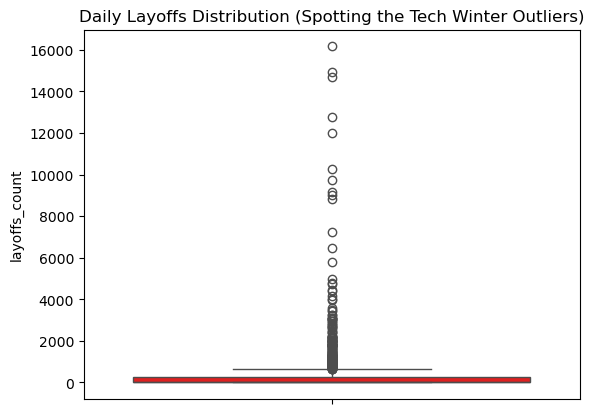

In [320]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drawing the box plot for Layoffs (Vertical layout)
sns.boxplot(y=master_df['layoffs_count'], color='red')
plt.title("Daily Layoffs Distribution (Spotting the Tech Winter Outliers)")
plt.show()

### 1. Layoff Outliers (Box Plot)

Before comparing the two datasets, I needed to understand the shape of the tech winter. I used a box plot here to see if layoffs were slow/steady or a series of massive shocks to the industry. As the extreme outliers show, the Tech Winter was defined by sudden, violent spikes in firings.

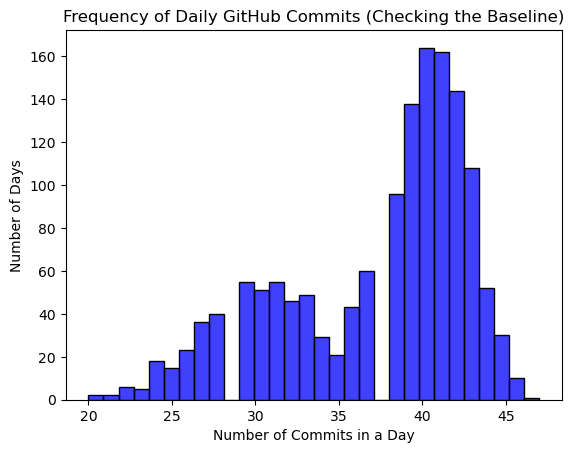

In [321]:
# Drawing the histogram for GitHub commits
sns.histplot(data=master_df, x='github_commits', bins=30, color='blue')
plt.title("Frequency of Daily GitHub Commits (Checking the Baseline)")
plt.xlabel("Number of Commits in a Day")
plt.ylabel("Number of Days")
plt.show()

### 2. GitHub Commits Distribution (Histogram)

Next, I needed to figure out what a "normal" day of open-source coding looks like. I built this histogram to find the baseline. As we can see, the data clusters around 35-40 commits per day, but there is a noticeable 'long tail' of highly active days that I want to investigate.

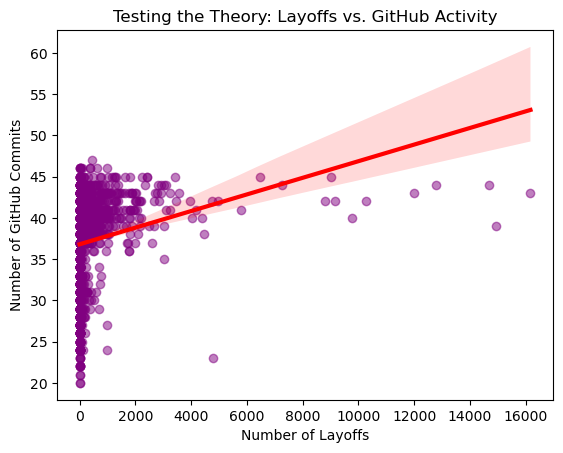

Pearson Correlation Coefficient: 0.21197594143728862


In [322]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drawing the regression plot (Scatter + Trendline)
sns.regplot(data=master_df, x='layoffs_count', y='github_commits', 
            scatter_kws={'color': 'purple', 'alpha': 0.5}, 
            line_kws={'color': 'red', 'linewidth': 3})

plt.title("Testing the Theory: Layoffs vs. GitHub Activity")
plt.xlabel("Number of Layoffs")
plt.ylabel("Number of GitHub Commits")
plt.show()

# Calculating the Pearson Correlation Coefficient
correlation = master_df['layoffs_count'].corr(master_df['github_commits'])
print(f"Pearson Correlation Coefficient: {correlation}")

### 3. Correlation Check (Scatterplot)

Here, I mapped the number of daily layoffs against the number of daily GitHub commits. By adding a regression trendline, I can visibly see that as the layoff count moves to the right, the coding activity pushes upward.


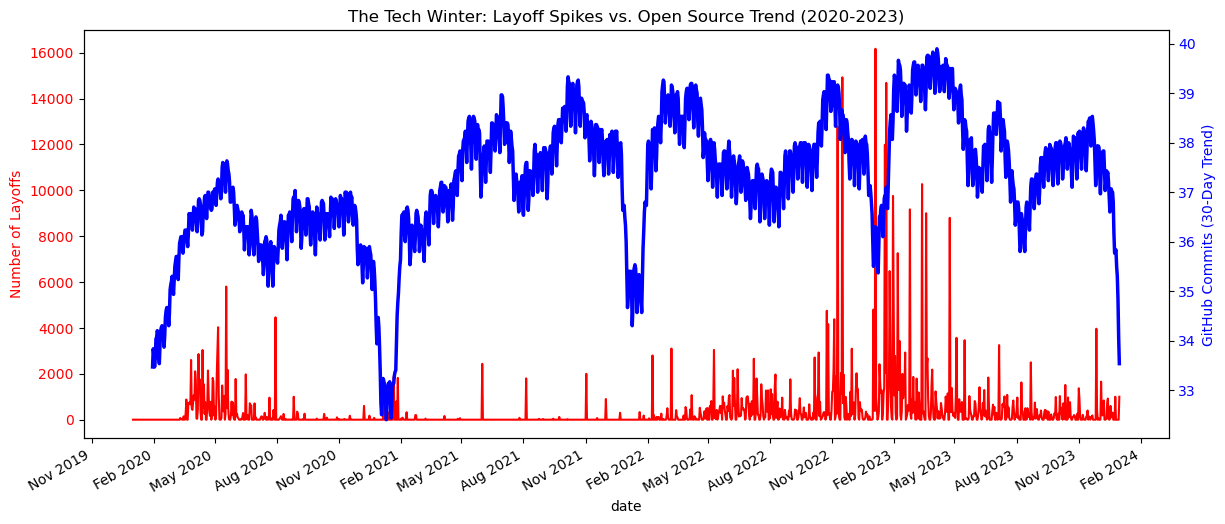

In [323]:
import matplotlib.dates as mdates

# Telling pandas this column is a timeline, not just text
master_df['date'] = pd.to_datetime(master_df['date'])

# 1. Applying a 30-day moving average to filter high-frequency cyclical variance
master_df['commits_trend'] = master_df['github_commits'].rolling(window=30).mean()

# 2. Creating the canvas
fig, ax1 = plt.subplots(figsize=(14, 6))

# 3. Plotting Layoffs on the left axis
sns.lineplot(data=master_df, x='date', y='layoffs_count', color='red', ax=ax1)
ax1.set_ylabel("Number of Layoffs", color='red')
ax1.tick_params(axis='y', labelcolor='red')

# 4. Plotting the Github Commits on the right axis
ax2 = ax1.twinx()
sns.lineplot(data=master_df, x='date', y='commits_trend', color='blue', ax=ax2, linewidth=2.5)
ax2.set_ylabel("GitHub Commits (30-Day Trend)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("The Tech Winter: Layoff Spikes vs. Open Source Trend (2020-2023)")

# 5. Formatting the X-axis to display quarterly chronological markers
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
fig.autofmt_xdate()

plt.show()

### 4. Timeline: Layoffs vs. Github Commits (Dual-Axis)

I wanted to see how both of these variables moved together over the entire four-year period. But since daily GitHub commits bounce up and down so much (since people code way less on weekends), the raw graph was too crowded to read easily. To fix this, I applied a 30-day rolling average to the GitHub data to smooth out those inconsistencies caused by weekends and expose the actual, long-term trend.

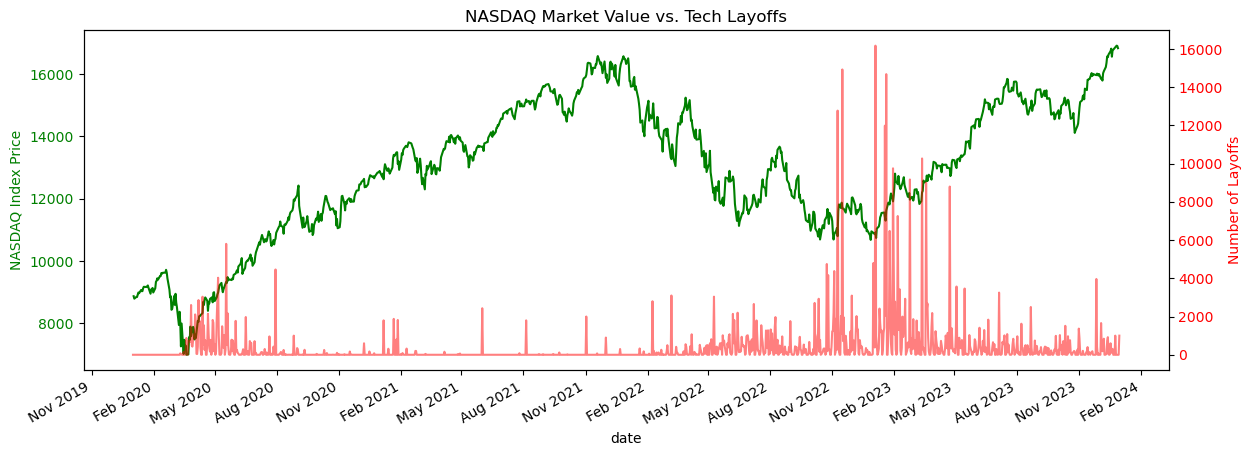

In [324]:
# Exploring the macroeconomic angle: NASDAQ vs. Layoffs
fig, ax1 = plt.subplots(figsize=(14, 5))

# Plotting the NASDAQ index on the left axis
sns.lineplot(data=master_df, x='date', y='nasdaq_price', color='green', ax=ax1)
ax1.set_ylabel("NASDAQ Index Price", color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Setting up a twin axis to overlay the layoff counts on the right
ax2 = ax1.twinx()
sns.lineplot(data=master_df, x='date', y='layoffs_count', color='red', ax=ax2, alpha=0.5)
ax2.set_ylabel("Number of Layoffs", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("NASDAQ Market Value vs. Tech Layoffs")

# Formatting the timeline so it's readable
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

plt.show()

### 5. Timeline: Layoffs vs. NASDAQ (Dual-Axis)

Even though my main question is whether layoffs drove open-source activity, it is important to look at the broader economic environment. I added this single dual-axis chart to confirm that the massive spikes in tech layoffs actually lined up with the stock market data of historic crash of the NASDAQ.

In [325]:
from scipy.stats import pearsonr

# Running the formal hypothesis test
stat, p_value = pearsonr(master_df['layoffs_count'], master_df['github_commits'])

# Printing the exact mathematical results
print("--- HYPOTHESIS TEST 1 (GITHUB COMMITS vs. LAYOFFS) ---")
print(f"Pearson Correlation (r): {stat:.3f}")
print(f"P-Value: {p_value}")

# Interpreting the p-value against the 0.05 alpha threshold
print("\n--- THE FINAL RESULT ---")
if p_value < 0.05:
    print("Null Hypothesis rejected.")
    print("The positive correlation is statistically significant. The theory is mathematically proven.")
else:
    print("Failed to reject the Null Hypothesis.")
    print("The correlation is not statistically significant. It could be a consequence of randomness.")

--- HYPOTHESIS TEST 1 (GITHUB COMMITS vs. LAYOFFS) ---
Pearson Correlation (r): 0.212
P-Value: 2.6416071126427795e-16

--- THE FINAL RESULT ---
Null Hypothesis rejected.
The positive correlation is statistically significant. The theory is mathematically proven.


### Hypothesis Test 1: The Core Trend (Pearson Correlation)

The scatter plot and timeline strongly suggest a positive relationship, but I need to prove it mathematically. I am using a Pearson Correlation test to confirm that the upward trend in open-source coding is statistically linked to the volume of layoffs.

Null Hypothesis (H0): There is no linear relationship between daily tech layoffs and daily GitHub commits. The correlation is exactly zero.

Alternative Hypothesis (HA): There is a significant positive correlation between daily tech layoffs and daily GitHub commits.

Significance Level (Alpha): 0.05

In [326]:
# I have to drop the days where the stock market was closed (like weekends/holidays) so the math actually works
nasdaq_test_df = master_df.dropna(subset=['nasdaq_price'])

# Running the Pearson correlation test
stat_nasdaq, p_value_nasdaq = pearsonr(nasdaq_test_df['nasdaq_price'], nasdaq_test_df['layoffs_count'])

print("--- HYPOTHESIS TEST 2 (NASDAQ vs. LAYOFFS) ---")
print(f"Pearson Correlation (r): {stat_nasdaq:.3f}")
print(f"P-Value: {p_value_nasdaq}")

# Interpreting the p-value against the 0.05 alpha threshold
print("\n--- THE FINAL RESULT ---")
if p_value_nasdaq < 0.05:
    print("Null Hypothesis rejected.")
    print("There is a statistically significant relationship between the dropping NASDAQ price and tech layoffs. The theory is mathematically proven.")
else:
    print("Failed to reject the Null Hypothesis.")
    print("The relationship is not statistically significant. It could be a consequence of randomness.")

--- HYPOTHESIS TEST 2 (NASDAQ vs. LAYOFFS) ---
Pearson Correlation (r): -0.150
P-Value: 1.8290481296927702e-06

--- THE FINAL RESULT ---
Null Hypothesis rejected.
There is a statistically significant relationship between the dropping NASDAQ price and tech layoffs. The theory is mathematically proven.


### Hypothesis Test 2: The Macroeconomic Context (Pearson Correlation)

Even though my first test already proved the link between GitHub commits and layoffs, it is important to back up the macroeconomic side. I ran this second test to confirm that the historic crash of the NASDAQ actually mathematically correlates with the massive wave of tech layoffs.

Null Hypothesis (H0): There is no linear relationship between the daily NASDAQ price and the number of tech layoffs.

Alternative Hypothesis (HA): There is a significant negative correlation between the NASDAQ price and tech layoffs (as the market drops, layoffs rise).

Significance Level (Alpha): 0.05

In [327]:
from scipy.stats import ttest_ind

# Splitting the data into two distinct groups
peaceful_days = master_df[master_df['layoffs_count'] == 0]['github_commits']
panic_days = master_df[master_df['layoffs_count'] > 0]['github_commits']

# Running the Independent T-Test
t_stat, p_value_ttest = ttest_ind(peaceful_days, panic_days)

# Printing the results 
print("--- HYPOTHESIS TEST 3 (PEACEFUL vs. PANIC DAYS) ---")
print(f"Average Commits on Peaceful Days (0 layoffs): {peaceful_days.mean():.2f}")
print(f"Average Commits on Panic Days (1+ layoffs): {panic_days.mean():.2f}")
print(f"\nT-Statistic: {t_stat:.3f}")
print(f"P-Value: {p_value_ttest}")

print("\n--- THE FINAL RESULT ---")
if p_value_ttest < 0.05:
    print("Null Hypothesis rejected.")
    print("The difference is statistically significant. Developers really do code more on days when layoffs are happening.")
else:
    print("Failed to reject the Null Hypothesis.")
    print("The difference in averages isn't statistically significant enough to claim a shift.")

--- HYPOTHESIS TEST 3 (PEACEFUL vs. PANIC DAYS) ---
Average Commits on Peaceful Days (0 layoffs): 35.21
Average Commits on Panic Days (1+ layoffs): 39.77

T-Statistic: -16.750
P-Value: 9.815486486065254e-58

--- THE FINAL RESULT ---
Null Hypothesis rejected.
The difference is statistically significant. Developers really do code more on days when layoffs are happening.


### Hypothesis Test 3: The Behavioral Shift (Independent T-Test)

My first two tests proved the trends, but I wanted to look at the data one more way to be absolutely sure. I decided to split all 1461 days into two groups: "Peaceful Days" (zero tech layoffs) and "Panic Days" (at least one tech layoff). I’m using an Independent T-Test here to see if the average number of GitHub commits actually shifts on days when people are losing their jobs.

Null Hypothesis (H0): The average number of GitHub commits on Peaceful Days is exactly the same as on Panic Days.

Alternative Hypothesis (HA): There is a significant difference in the average number of GitHub commits between Peaceful Days and Panic Days.

Significance Level (Alpha): 0.05